Third Exercise: Auto-annotation + YOLO Training

In [1]:
# Uncomment to install if needed
#!pip install -q ultralytics
#!pip install -q ImageHash
#!pip install -q ftfy regex tqdm
#!pip install -q git+https://github.com/openai/CLIP.git

In [ ]:
from pathlib import Path
from getpass import getpass
import shutil, random
import os

import requests
from PIL import Image, ImageDraw
import cv2
import imagehash

import torch
import clip
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import matplotlib.pyplot as plt
import yaml

In [ ]:
Pexels_api_key = getpass("Enter Pexels api key: ")

In [4]:
# Here I am gonna define the api key and the url, then I download the pics 
pixels_urls = 'https://api.pexels.com/v1/search'
headers = {'Authorization': Pexels_api_key}
# Source: https://medium.com/%40minhlenguyen02/automating-image-search-and-download-with-the-pexels-api-module-7b50ad9e0ec1

In [5]:
# This is the main dataset setting.
# If I wanna another ds later, this is the only part i need to edit. 
classes = {"bicycle": 100, "laptop": 100, "pizza": 100}

# I save all downloaded images first.
raw_ds = Path("Pexels-dataset/Raw-data")
raw_ds.mkdir(parents=True, exist_ok=True)

In [6]:
#  I got some pics that did not look like the class, so I use here CLIP to filter 
device = "cuda" if torch.cuda.is_available() else 'cpu'
clip_model, preprocess = clip.load("ViT-B/32", device=device)
class_names = list(classes)
# Source: https://github.com/openai/CLIP

# I turn my class names into prompts for CLIP.
# Later, each downloaded image is compared with these prompts before I keep it. 
text = clip.tokenize([f"a photo of a {name}" for name in class_names]).to(device)

In [7]:
# In this cell, I preprocess the images

# if the cleaning becomes too strict or too weak, I can adjust them.
clip_confidence = 0.5
blur_min = 6
# I set a max page number 
max_pages = 25

# I create a function to compare the image with the class name. 
def comparing_img_VS_class(img, label):
    image = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        scores = clip_model(image, text)[0].softmax(dim=-1)[0]  
# I keep the image if the confidence is at least 0.5        
    correct_img = class_names.index(label)
    return scores.argmax().item() == correct_img and scores[correct_img].item() >= clip_confidence

def not_blurry(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(img, cv2.CV_64F).var() >= blur_min
# I used QWEN for debugging.
# Source: https://pyimagesearch.com/2015/09/07/blur-detection-with-opencv

In [8]:
# In this cell, I download and clean the images

# Empty report, so I can print to see each class
report = []

for label, collecting_img in classes.items():
# one folder per class. 
    folder = raw_ds / label
    folder.mkdir(parents=True, exist_ok=True)

# I keep my clean ds from duplicates.
    accepted_img = []
    too_small = miss_match = blur = accepted = duplicated = 0
    page = 1

    while len(accepted_img) < collecting_img and page <= max_pages:
# Because the Pexels allow max 80 images per page for having more the number of api call
        params = {'query': label, "per_page": 80, 'page': page}
        response = requests.get(pixels_urls, headers=headers, params=params, timeout=20)
        response.raise_for_status()
        photos = response.json().get("photos", [])

# I already kept enough clean images for this class
        for photo in photos:
            if len(accepted_img) >= collecting_img:
                break

# Pexels has different sizes of the same image, I choose the large.
# which is good balance, good enough quality, but not as heavy as original. 
            url = photo["src"]['large']
            path = folder / f"{photo['id']}.jpg"
           
# First I download the image and save it.
# After saving, I can open it with pillow and opencv 
            img_response = requests.get(url, timeout=20)
            img_response.raise_for_status()
            path.write_bytes(img_response.content)
            img = Image.open(path).convert('RGB')

# small image is not gonna be useful for training, so I remove them now.
            if min(img.size) < 200:
                path.unlink(missing_ok=True)
                too_small += 1
                continue

# I calculated perceptual hash before accepting the image
            img_hash = imagehash.phash(img)
# Since my DS is not that big, I have to get very close images. 
            if any(img_hash - old_hash <= 5 for old_hash in accepted_img):
                path.unlink(missing_ok=True)
                duplicated += 1
                continue

# After duplicate checking, I use clip to check the image meaning.
            if not comparing_img_VS_class(img, label):
                path.unlink(missing_ok=True)
                miss_match += 1
                continue

# I save the accepted image as jpeg
            if not not_blurry(path):
                path.unlink(missing_ok=True)
                blur += 1
                continue
            img.save(path, "JPEG", quality=95)
            accepted_img.append(img_hash)
            accepted += 1

        page += 1
    
# I save the result for this class so the next cell can print a clean summary.
    report.append([label, collecting_img, accepted, duplicated, miss_match, blur, too_small])
    print(f"{label}: Accepted={accepted}/{collecting_img}")
# Source: https://pypi.org/project/ImageHash
# For debugging, I used QWEN.

bicycle: Accepted=100/100
laptop: Accepted=100/100
pizza: Accepted=100/100


In [9]:
for label, collecting_img, accepted, duplicated, miss_match, blur, too_small in report:
    print(f"{label}: accepted={accepted}, Too small={too_small}, duplicated={duplicated}, Miss match images={miss_match}, blur={blur}")

bicycle: accepted=100, Too small=0, duplicated=0, Miss match images=0, blur=0
laptop: accepted=100, Too small=0, duplicated=3, Miss match images=0, blur=0
pizza: accepted=100, Too small=0, duplicated=2, Miss match images=0, blur=0


Auto-annotation with YOLO-World

In [ ]:
yolo_world = YOLO('yolov8s-worldv2.pt')
yolo_world.set_classes(list(classes))
# Source: https://docs.ultralytics.com/models/yolo-world/

In [40]:
# I gonna  keep only detections that match the image folder class.
labels_raw = Path('Pexels-dataset/labels_raw')
class_ids = {label: number for number, label in enumerate(class_names)}
if labels_raw.exists():
    shutil.rmtree(labels_raw) 
saved= 0
skipped = 0

for label in class_names:
    label_path= labels_raw / label
    label_path.mkdir(parents=True, exist_ok=True)
    expected_id = class_ids[label]


    for img_path in sorted((raw_ds /label).glob('*.jpg')):
        result= yolo_world.predict(str(img_path),conf=0.25, verbose=False)[0]
        lines = []

        for class_id, xywh in zip(result.boxes.cls, result.boxes.xywhn):
            if int(class_id) == expected_id:
                center_x, center_y, box_width,box_height = xywh.tolist()
                lines.append(f"{expected_id} {center_x:.6f} {center_y:.6f} {box_width:.6f} {box_height:.6f}")

        if lines:
            (label_path / f"{img_path.stem}.txt").write_text("\n".join(lines))
            saved += 1
        else:
            skipped += 1
print(f"Auto annotation is done: saved={saved}, skipped={skipped}")
# Source: https://docs.ultralytics.com/reference/engine/results

Auto annotation is done: saved=292, skipped=6


Build YOLO dataset

In [ ]:
# I gather all annotated images then copy them into the YOLO ds folder structure.

yolo_ds = Path("Pexels-dataset/yolo_dataset")
if yolo_ds.exists():
    shutil.rmtree(yolo_ds)

img_paths = []
img_labels= []

for label in class_names:
    for txt_path in sorted((labels_raw / label).glob("*.txt")):
        img_paths.append(raw_ds / label / f"{txt_path.stem}.jpg")
        img_labels.append(label)

train_paths, val_paths, train_labels, val_labels = train_test_split(img_paths,img_labels, test_size=0.2,
                                                                    stratify=img_labels, random_state=42)

for split_name, split_paths, split_labels in [("train", train_paths, train_labels), ('val', val_paths, val_labels)]:
    img_dir = yolo_ds /'images'/split_name
    label_dir= yolo_ds / "labels" / split_name
    img_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)

    for img_path, label in zip(split_paths, split_labels):
        shutil.copy(img_path, img_dir / img_path.name)
        shutil.copy(labels_raw / label / f"{img_path.stem}.txt", label_dir / f"{img_path.stem}.txt")

print(f"YOLO DS: train={len(train_paths)}, val={len(val_paths)}")
# Source: https://docs.ultralytics.com/datasets/detect

YOLO DS: train=233, val=59


In [ ]:
# In this cell, I am gonna write data.yaml so yolo can find the ds.
data_yaml_path = yolo_ds / 'data.yaml'

data_yaml = {'path': str(yolo_ds.resolve()),"train":'images/train',
            "val":"images/val", "names":{Class_id: name for Class_id, name in enumerate(class_names)}}

data_yaml_path.write_text(yaml.safe_dump(data_yaml, sort_keys=False))
print(data_yaml_path.read_text())

path: D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\Pexels-dataset\yolo_dataset
train: images/train
val: images/val
names:
  0: bicycle
  1: laptop
  2: pizza



Train YOLO

In [ ]:
# I train the final model
train_model = YOLO("yolov8n.pt")
train_model.train(data=str(data_yaml_path), epochs=30, imgsz=640,
                  batch=16,project='yolo_runs',name="exp")

best_weights = Path(train_model.trainer.best)
print(f'Best weights: {best_weights}')

Ultralytics 8.4.48  Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Pexels-dataset\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

d:\ML_DE\Cloud_Based_Machine_Learning\.venv\Lib\site-packages\ultralytics\nn\modules\block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:217.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
d:\ML_DE\Cloud_Based_Machine_Learning\.venv\Lib\site-packages\ultralytics\nn\modules\block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::C

AMP: checks passed 
train: Fast image access  (ping: 0.00.0 ms, read: 28.121.3 MB/s, size: 143.6 KB)
train: Scanning D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\Pexels-dataset\yolo_dataset\labels\train.cache... 233 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233  0.0s
val: Fast image access  (ping: 0.00.0 ms, read: 14.910.6 MB/s, size: 109.5 KB)
val: Scanning D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\Pexels-dataset\yolo_dataset\labels\val.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59  0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\runs\detect\yolo_runs\exp-4\labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader wor

d:\ML_DE\Cloud_Based_Machine_Learning\.venv\Lib\site-packages\ultralytics\utils\loss.py:390: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:217.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       1/30      3.34G     0.6852      2.816      1.238         29        640: 100% ━━━━━━━━━━━━ 15/15 3.3it/s 4.6s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.7it/s 0.7s1.6s
                   all         59         68    0.00382      0.988      0.637      0.524

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      3.64G     0.9396      2.168      1.474         54        640: 0% ──────────── 0/15  0.2s

...

      28/30      3.64G     0.3395     0.7004     0.9571         13        640: 100% ━━━━━━━━━━━━ 15/15 10.3it/s 1.5s.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.9it/s 0.3s0.5s
                   all         59         68      0.919      0.901      0.949      0.812

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/30      3.64G     0.3177     0.6586     0.9348         17        640: 7% ╸─────────── 1/15 1.8it/s 0.2s<7.8s

d:\ML_DE\Cloud_Based_Machine_Learning\.venv\Lib\site-packages\ultralytics\utils\loss.py:390: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:217.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      29/30      3.64G     0.3308     0.6614     0.9477         11        640: 100% ━━━━━━━━━━━━ 15/15 10.7it/s 1.4s.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.8it/s 0.3s0.5s
                   all         59         68      0.917      0.904      0.948      0.798

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30      3.64G     0.2728     0.6269     0.8753         20        640: 0% ──────────── 0/15  0.1s

d:\ML_DE\Cloud_Based_Machine_Learning\.venv\Lib\site-packages\ultralytics\utils\loss.py:390: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:217.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      30/30      3.64G     0.3012     0.6355     0.9289         15        640: 100% ━━━━━━━━━━━━ 15/15 10.4it/s 1.4s.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.6it/s 0.3s0.5s
                   all         59         68       0.92      0.905      0.951      0.805

30 epochs completed in 0.023 hours.
Optimizer stripped from D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\runs\detect\yolo_runs\exp-4\weights\last.pt, 6.2MB
Optimizer stripped from D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\runs\detect\yolo_runs\exp-4\weights\best.pt, 6.2MB

Validating D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\runs\detect\yolo_runs\exp-4\weights\best.pt...
Ultralytics 8.4.48  Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP

In [ ]:
# What I can see from output, the The model looks  confident. but recall is not that good,it missed some objects. 
# Pizza is my strongest class overall.


Evaluation

In [49]:
# I validate the best model on validation images.
eval_model = YOLO(str(best_weights))
metrics = eval_model.val(data=str(data_yaml_path), split="val")
print(metrics)

Ultralytics 8.4.48  Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1055.5448.4 MB/s, size: 102.8 KB)
val: Scanning D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\Pexels-dataset\yolo_dataset\labels\val.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6it/s 2.5s0.5ss
                   all         59         68      0.975      0.874      0.956      0.815
               bicycle         20         20          1      0.929      0.969      0.785
                laptop         19         20      0.973        0.8      0.926      0.815
                 pizza         20         28       0.95      0.893      0.973      0.845
Speed: 2.4ms preprocess, 1.6ms inference, 0.0ms loss, 1.5ms postprocess per

In [ ]:
# Laptop recall is lower, so laptop images need manual checking first.

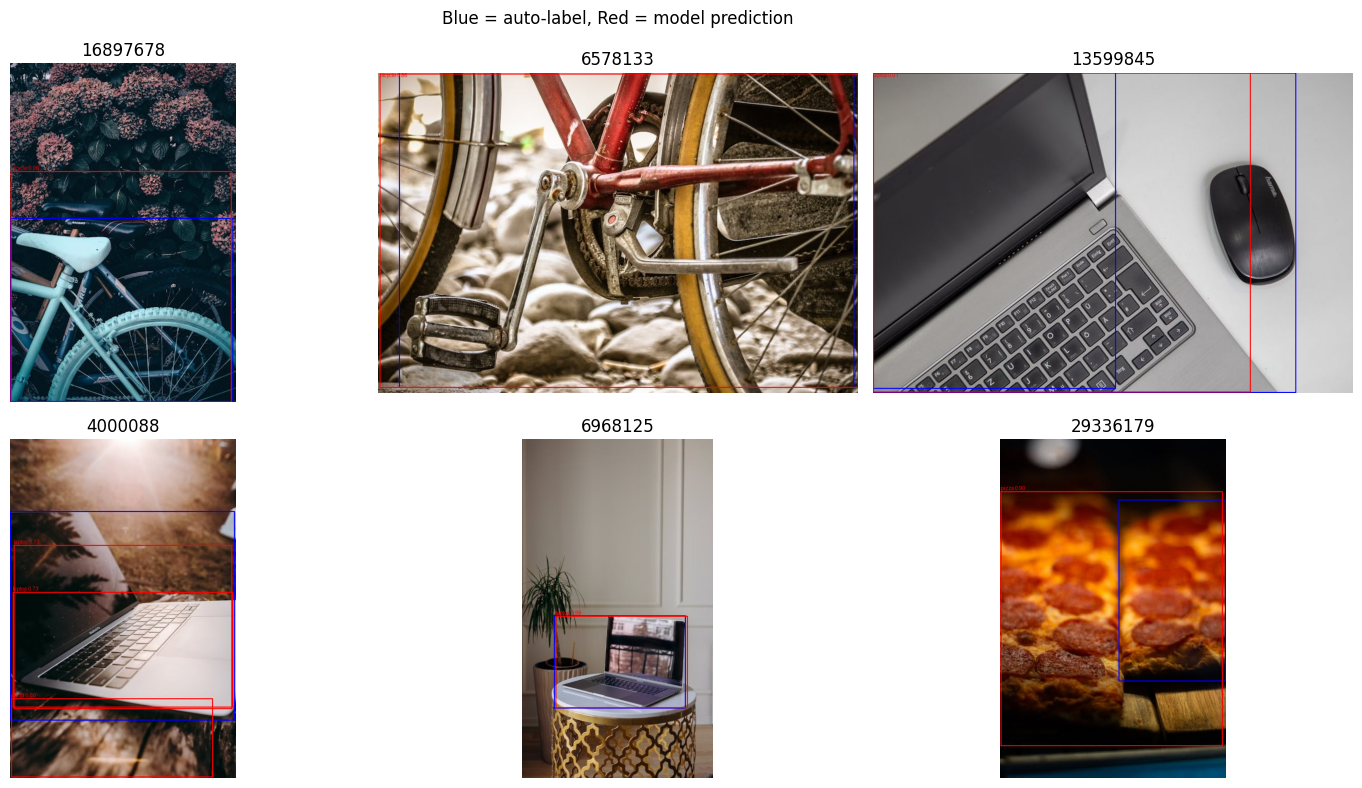

In [ ]:
# I am gonna  compare auto labels and model predictions.
val_imgs = sorted((yolo_ds/ "images" / "val").glob("*.jpg"))
sample = random.sample(val_imgs, min(6, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, img_path in zip(axes, sample):
    img= Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img)
    width, height =img.size

    for line in (yolo_ds / "labels" / "val" / f"{img_path.stem}.txt").read_text().splitlines():
        _, cx, cy, bw, bh = map(float, line.split())
        box = [int((cx - bw / 2)*width),int((cy -bh / 2)*height),int((cx + bw / 2)*width),int((cy + bh / 2)*height)]
        draw.rectangle(box, outline='blue', width=2)
    result = eval_model.predict(str(img_path), conf=0.25, verbose=False)[0]

    for box in result.boxes.xyxy:
        draw.rectangle([int(v) for v in box.tolist()], outline='red', width=2)
    ax.imshow(img)
    ax.set_title(img_path.stem[:20])
    ax.set_axis_off()

for ax in axes[len(sample):]:
    ax.set_axis_off()

plt.suptitle("Blue = auto-label, Red = model prediction", fontsize=12)
plt.tight_layout()
plt.show()
# For debugging, I used QWEN.

In [ ]:
# As I said before, laptop is the weakest class. The ds has auto label noise, but still the merics are not bad.
# If I annotate laptop images manually, I believe  the merics can be improved a lot.